## Inteligență Artificială  Tema 1 - 2025: Sokoban

Responsabili:
- Andrei Olaru
- Cătălin Chiru
- Andrei Dugăeșescu
- Mihai Nan
- Vlad Matei Drăghici
- Alexandru Baciu
- Bogdan-Andrei Sprîncenatu

In [ ]:
from sokoban import Map
from search_methods.solver import Solver
from search_methods.heuristics import *
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Creating a map 

In [2]:
# Maps can be created using the Map class
map_from_init = Map(5, 5, 0, 0, [('box1', 1, 3)], [(4, 4)], [(3,3), (3,4), (3,1)], 'easy_map1')

# Maps can be created through yaml files
map_from_yaml = Map.from_yaml('tests/easy_map1.yaml')

assert str(map_from_init) == str(map_from_yaml), "Reading from yaml file Failed"

In [3]:
# Maps can also be created from their string representation
map_str = str(map_from_init)
map_from_str = Map.from_str(map_str)

assert str(map_from_init) == str(map_from_str), "String conversion Failed"

# Solving a map 

In [ ]:
map = Map.from_yaml('tests/super_hard_map1.yaml')

# Visualizing a map 

In [5]:
print(map)


/ _ _ _ / 
/ _ B B _ 
/ _ _ _ / 
_ / _ B X 
_ _ P B B 
_ X _ X X 
_ _ _ _ / 
X _ _ _ / 


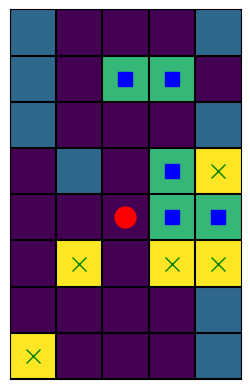

In [6]:
map.plot_map()

In [7]:
# To save the state of a map to disk:
map.save_map('images', 'easy_map1_init.png')

In [8]:
solver = Solver(map)

print("Solving with IDA*...")
solution = solver.solve(algorithm='ida_star', use_pull_moves=True)
if solution:
    print(f"Solution found with {len(solution)} moves")
    print("Moves:", solution)
    
    # Visualize solution
    solver.visualize_solution('images_ida_star')
    solver.visualize_solution('images')
else:
    print("No solution found!")

Solving with IDA*...
Starting IDA* with initial bound: 77
Increasing bound to 78, explored: 5 states
Increasing bound to 79, explored: 64387 states
Solution found! Explored: 136890 states
Pruned: 67334 states
Max depth: 72
solution length: 53
Time: 34.59 seconds
Solution found with 53 moves
Moves: [3, 2, 4, 1, 4, 2, 3, 1, 3, 3, 1, 3, 3, 2, 4, 4, 4, 3, 3, 3, 2, 4, 4, 4, 4, 1, 2, 5, 1, 2, 5, 4, 2, 3, 2, 3, 3, 1, 4, 4, 4, 4, 2, 4, 1, 1, 3, 1, 3, 8, 2, 3, 6]
GIF saved at: images_ida_star/solution.gif
Solution visualization saved to images_ida_star/solution.gif
GIF saved at: images/solution.gif
Solution visualization saved to images/solution.gif


In [9]:
solver = Solver(map)

print("Solving with Simulated annealing...")
solution = solver.solve(
    algorithm='simulated_annealing',
    use_pull_moves=True,
    heuristic_func = sokoban_simple_heuristic
)



if solution:
    print(f"Solution found with {len(solution)} moves")
    print("Moves:", solution)
    
    # Visualize solution
    solver.visualize_solution('images_simulated_anealing')
    solver.visualize_solution('images')
else:
    print("No solution found!")

Solving with Simulated annealing...
Solution found with 114 moves
Moves: [3, 6, 1, 4, 5, 5, 4, 2, 2, 3, 2, 5, 4, 2, 7, 1, 3, 3, 8, 8, 8, 8, 1, 3, 2, 3, 3, 3, 2, 4, 3, 8, 1, 3, 3, 2, 4, 3, 1, 1, 4, 2, 4, 4, 6, 1, 3, 3, 2, 4, 1, 4, 4, 4, 1, 3, 1, 3, 6, 4, 2, 5, 5, 4, 2, 2, 3, 8, 4, 2, 3, 3, 8, 1, 1, 1, 3, 3, 2, 2, 7, 7, 3, 1, 3, 2, 2, 4, 4, 4, 4, 1, 8, 6, 1, 3, 2, 5, 8, 8, 2, 3, 8, 4, 1, 1, 3, 8, 2, 3, 5, 3, 5, 4]
GIF saved at: images_simulated_anealing/solution.gif
Solution visualization saved to images_simulated_anealing/solution.gif
GIF saved at: images/solution.gif
Solution visualization saved to images/solution.gif


In [10]:
#Create dataframe for computing statistics using pandas


results = {
    'map': [],
    'algorithm': [],
    'use_pull': [],
    'execution_time': [],
    'states_explored': [],
    'solution_length': [],
    'pull_moves': []
}

# Test maps
test_maps = [
    'tests/easy_map1.yaml',
    'tests/easy_map2.yaml',
    'tests/hard_map1.yaml',
    'tests/hard_map2.yaml',
    'tests/large_map1.yaml',
    'tests/large_map2.yaml',
    'tests/medium_map1.yaml',
    'tests/medium_map2.yaml',
    'tests/super_hard_map1.yaml'
]

# Run tests
for map_file in test_maps:
    print(f"Testing on map: {map_file}")
    map_name = map_file.split('/')[-1].split('.')[0]
    
    use_pull = True
    try:
        map_obj = Map.from_yaml(map_file)
        solver = Solver(map_obj)
        
        start_time = time.time()
        solution = solver.solve(algorithm='ida_star', use_pull_moves=use_pull)
        end_time = time.time()
        
        if solution:
            pull_count = sum(1 for move in solution if move > 4)
            
            results['map'].append(map_name)
            results['algorithm'].append('IDA*')
            results['use_pull'].append(use_pull)
            results['execution_time'].append(end_time - start_time)
            results['states_explored'].append(map_obj.explored_states)
            results['solution_length'].append(len(solution))
            results['pull_moves'].append(pull_count)
            
            print(f"IDA* (pull={use_pull}): Solution with {len(solution)} moves in {end_time-start_time:.2f}s, {pull_count} pull moves")
        else:
            print(f"IDA* (pull={use_pull}): No solution found")
    except Exception as e:
        print(f"Error with IDA* on {map_name}: {e}")
    
    use_pull = True
    try:
        map_obj = Map.from_yaml(map_file)
        solver = Solver(map_obj)
        
        start_time = time.time()
        solution = solver.solve(algorithm='simulated_annealing', use_pull_moves=use_pull)
        end_time = time.time()
        
        if solution:
            pull_count = sum(1 for move in solution if move > 4)
            
            results['map'].append(map_name)
            results['algorithm'].append('SimulatedAnnealing')
            results['use_pull'].append(use_pull)
            results['execution_time'].append(end_time - start_time)
            results['states_explored'].append(map_obj.explored_states)
            results['solution_length'].append(len(solution))
            results['pull_moves'].append(pull_count)
            
            print(f"SA (pull={use_pull}): Solution with {len(solution)} moves in {end_time-start_time:.2f}s, {pull_count} pull moves")
        else:
            print(f"SA (pull={use_pull}): No solution found")
    except Exception as e:
        print(f"Error with SA on {map_name}: {e}")

df = pd.DataFrame(results)

Testing on map: tests/easy_map1.yaml
Starting IDA* with initial bound: 21
Increasing bound to 22, explored: 9 states
Increasing bound to 23, explored: 43 states
Increasing bound to 24, explored: 86 states
Increasing bound to 25, explored: 178 states
Increasing bound to 26, explored: 301 states
Increasing bound to 27, explored: 471 states
Increasing bound to 28, explored: 693 states
Increasing bound to 29, explored: 1035 states
Increasing bound to 30, explored: 1446 states
Increasing bound to 31, explored: 2195 states
Increasing bound to 32, explored: 3080 states
Increasing bound to 33, explored: 4277 states
Increasing bound to 34, explored: 5703 states
Solution found! Explored: 6201 states
Pruned: 2615 states
Max depth: 25
solution length: 19
Time: 1.17 seconds
IDA* (pull=True): Solution with 19 moves in 1.17s, 0 pull moves
SA (pull=True): Solution with 31 moves in 1.79s, 6 pull moves
Testing on map: tests/easy_map2.yaml
Starting IDA* with initial bound: 22
Increasing bound to 24, expl

In [11]:
results_heuristics = {
    'map': [],
    'algorithm': [],
    'heuristic': [],
    'use_pull': [],
    'execution_time': [],
    'states_explored': [],
    'solution_length': [],
    'pull_moves': []
}  

test_maps_heuristic = [
    'tests/easy_map1.yaml',
    'tests/easy_map2.yaml',
    'tests/hard_map1.yaml',
    'tests/hard_map2.yaml',
    'tests/large_map1.yaml',
    'tests/large_map2.yaml',
    'tests/medium_map1.yaml',
    'tests/medium_map2.yaml',
    'tests/super_hard_map1.yaml'
]


for map_file in test_maps_heuristic:
    print(f"Testing on map: {map_file}")
    map_name = map_file.split('/')[-1].split('.')[0]
    use_pull = True
    
    # Test with advanced heuristic
    try:
        map_obj = Map.from_yaml(map_file)
        solver = Solver(map_obj)
        start_time = time.time()
        solution = solver.solve(algorithm='ida_star', use_pull_moves=use_pull, 
                              heuristic_func=sokoban_advanced_heuristic)  # Default heuristic
        end_time = time.time()
        
        if solution:
            pull_count = sum(1 for move in solution if move > 4)
            results_heuristics['map'].append(map_name)
            results_heuristics['algorithm'].append('IDA*')
            results_heuristics['heuristic'].append('Advanced')
            results_heuristics['use_pull'].append(use_pull)
            results_heuristics['execution_time'].append(end_time - start_time)
            results_heuristics['states_explored'].append(map_obj.explored_states)
            results_heuristics['solution_length'].append(len(solution))
            results_heuristics['pull_moves'].append(pull_count)
            print(f"IDA* advanced (pull={use_pull}): Solution with {len(solution)} moves in {end_time-start_time:.2f}s, {pull_count} pull moves")
        else:
            print(f"IDA* advanced (pull={use_pull}): No solution found")
    except Exception as e:
        print(f"Error with IDA* advanced on {map_name}: {e}")
    
    # Test with simple heuristic
    try:
        map_obj = Map.from_yaml(map_file)
        solver = Solver(map_obj)
        start_time = time.time()
        solution = solver.solve(algorithm='ida_star', use_pull_moves=use_pull,
                              heuristic_func=sokoban_simple_heuristic)  # Simple heuristic
        end_time = time.time()
        
        if solution:
            pull_count = sum(1 for move in solution if move > 4)
            results_heuristics['map'].append(map_name)
            results_heuristics['algorithm'].append('IDA*')
            results_heuristics['heuristic'].append('Simple')
            results_heuristics['use_pull'].append(use_pull)
            results_heuristics['execution_time'].append(end_time - start_time)
            results_heuristics['states_explored'].append(map_obj.explored_states)
            results_heuristics['solution_length'].append(len(solution))
            results_heuristics['pull_moves'].append(pull_count)
            print(f"IDA* Simple (pull={use_pull}): Solution with {len(solution)} moves in {end_time-start_time:.2f}s, {pull_count} pull moves")
        else:
            print(f"IDA* Simple (pull={use_pull}): No solution found")
    except Exception as e:
        print(f"Error with IDA* Simple on {map_name}: {e}")




Testing on map: tests/easy_map1.yaml
Starting IDA* with initial bound: 21
Increasing bound to 22, explored: 9 states
Increasing bound to 23, explored: 43 states
Increasing bound to 24, explored: 86 states
Increasing bound to 25, explored: 178 states
Increasing bound to 26, explored: 301 states
Increasing bound to 27, explored: 471 states
Increasing bound to 28, explored: 693 states
Increasing bound to 29, explored: 1035 states
Increasing bound to 30, explored: 1446 states
Increasing bound to 31, explored: 2195 states
Increasing bound to 32, explored: 3080 states
Increasing bound to 33, explored: 4277 states
Increasing bound to 34, explored: 5703 states
Solution found! Explored: 6201 states
Pruned: 2615 states
Max depth: 25
solution length: 19
Time: 0.93 seconds
IDA* advanced (pull=True): Solution with 19 moves in 0.94s, 0 pull moves
Starting IDA* with initial bound: 12
Increasing bound to 13, explored: 34 states
Increasing bound to 14, explored: 97 states
Increasing bound to 15, explor

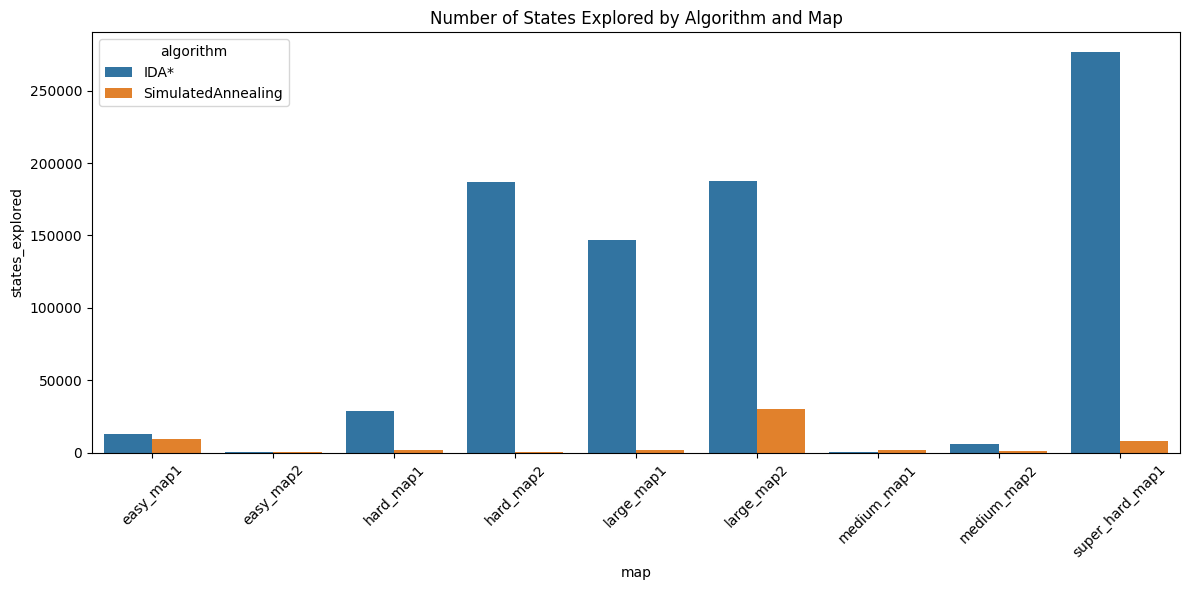

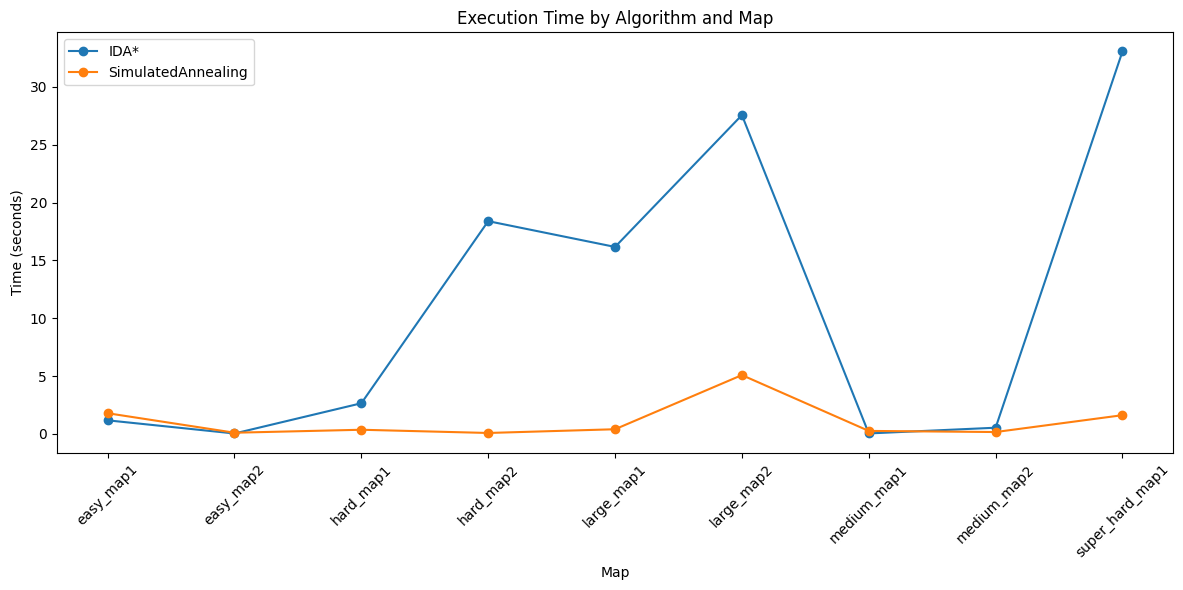

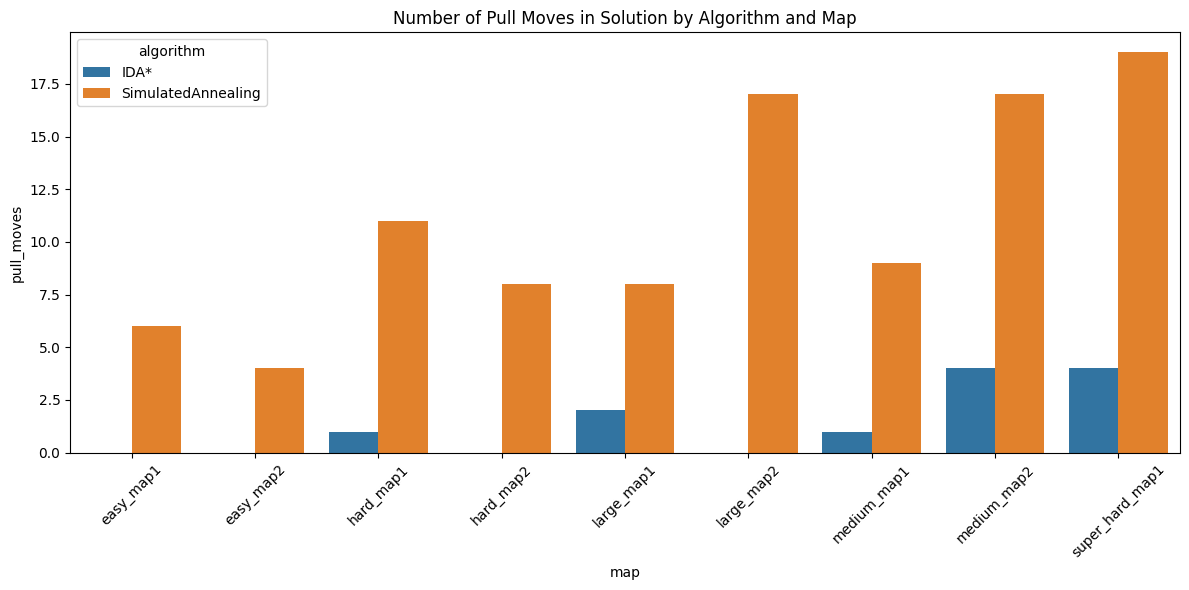

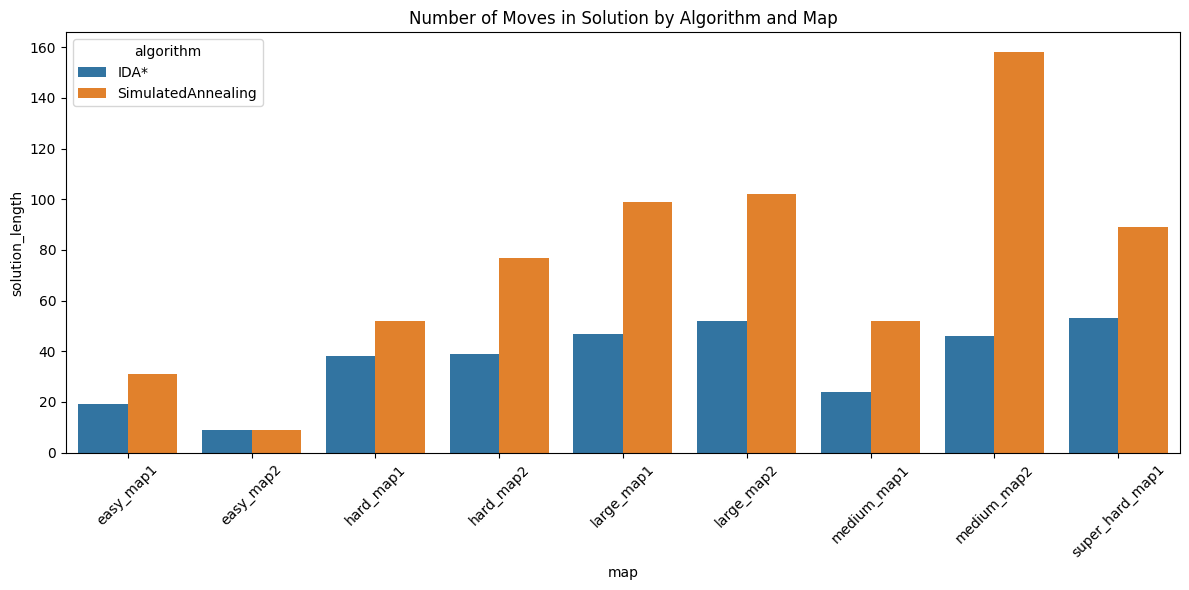

In [12]:
# Bar plot for states explored
plt.figure(figsize=(12, 6))
sns.barplot(x='map', y='states_explored', hue='algorithm', data=df)
plt.title('Number of States Explored by Algorithm and Map')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('states_explored.png')
plt.show()

# Line graph for execution times
plt.figure(figsize=(12, 6))
for algo in df['algorithm'].unique():
    algo_data = df[df['algorithm'] == algo]
    plt.plot(algo_data['map'], algo_data['execution_time'], label=algo, marker='o')
plt.title('Execution Time by Algorithm and Map')
plt.xlabel('Map')
plt.ylabel('Time (seconds)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('execution_times.png')
plt.show()

# Bar plot for pull moves
plt.figure(figsize=(12, 6))
sns.barplot(x='map', y='pull_moves', hue='algorithm', data=df[df['use_pull'] == True])
plt.title('Number of Pull Moves in Solution by Algorithm and Map')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pull_moves.png')
plt.show()


# Bar plot for solution length
plt.figure(figsize=(12, 6))
sns.barplot(x='map', y='solution_length', hue='algorithm', data=df[df['use_pull'] == True])
plt.title('Number of Moves in Solution by Algorithm and Map')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('moves.png')
plt.show()

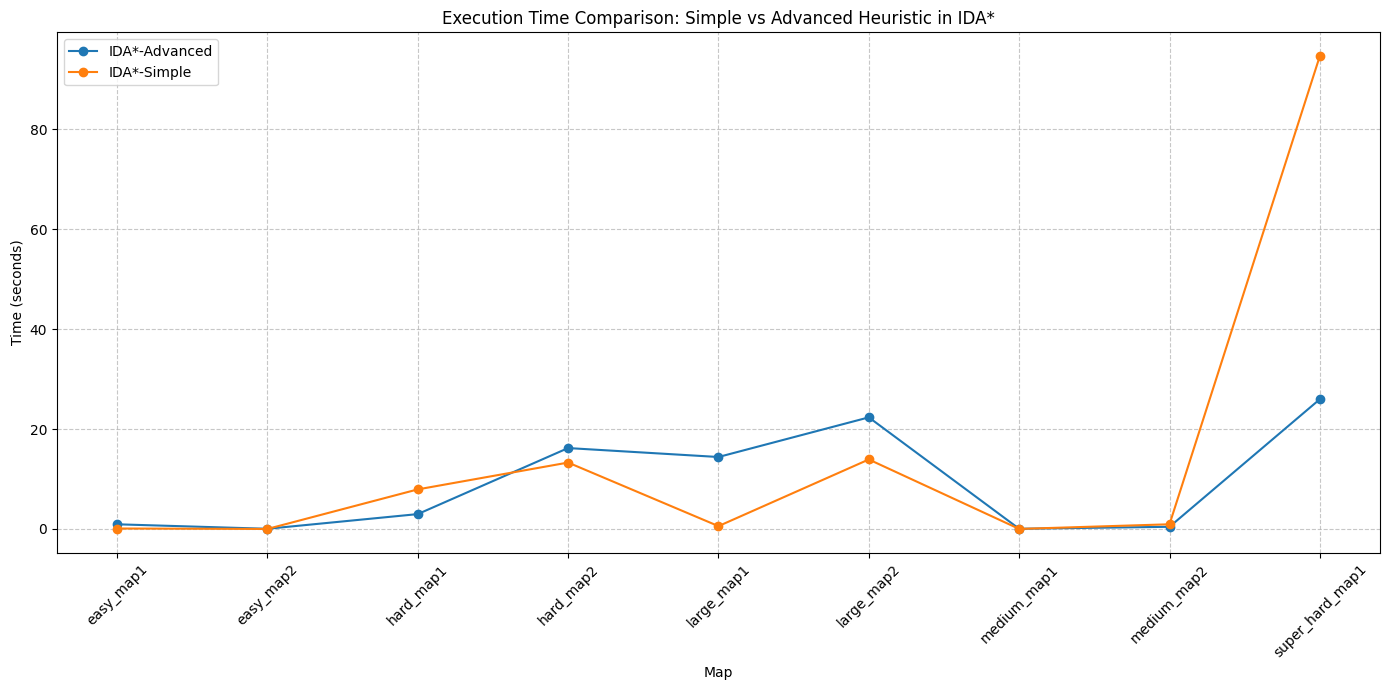

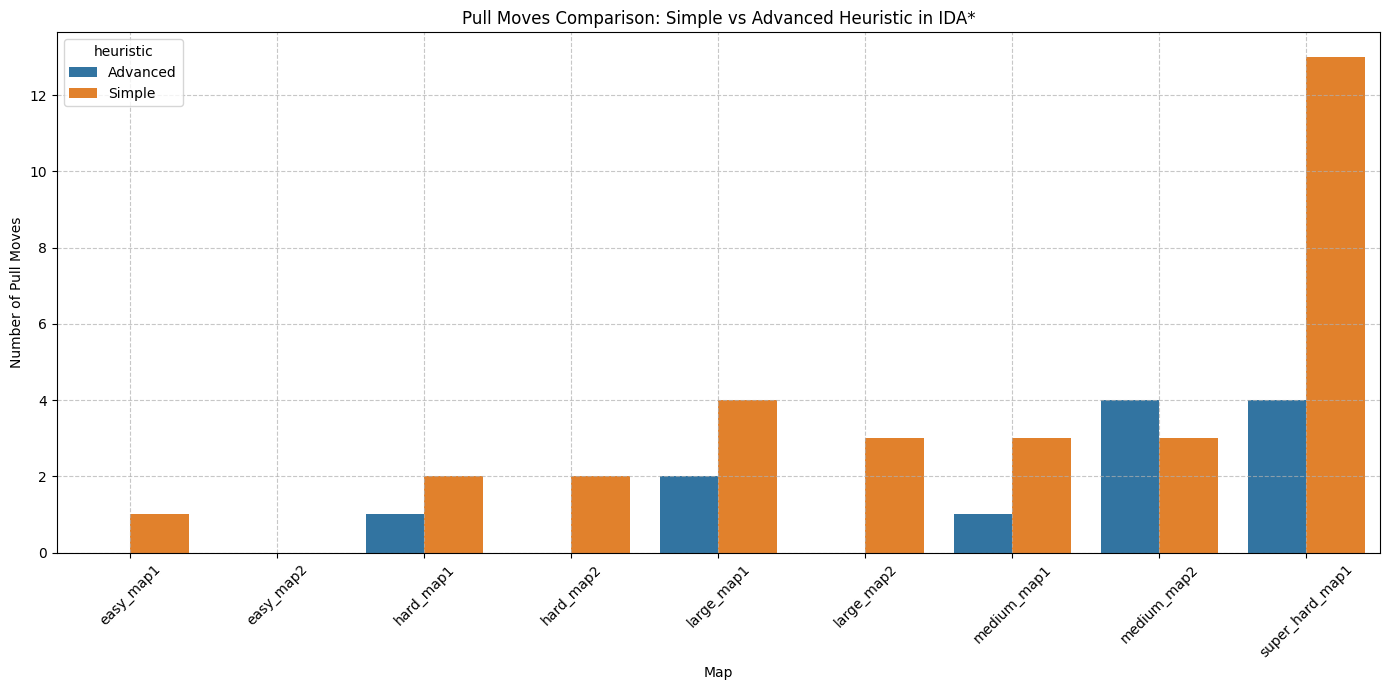

In [13]:
df2 = pd.DataFrame(results_heuristics)

# Create algorithm+heuristic combination for plotting
df2['algo_heuristic'] = df2['algorithm'] + "-" + df2['heuristic']

# Filter only IDA* results
sa_df = df2[df2['algorithm'] == 'IDA*']

# Line graph for execution times comparing heuristics
plt.figure(figsize=(14, 7))
for heuristic in sa_df['heuristic'].unique():
    h_data = sa_df[sa_df['heuristic'] == heuristic]
    plt.plot(h_data['map'], h_data['execution_time'], 
             label=f'IDA*-{heuristic}', 
             marker='o')

plt.title('Execution Time Comparison: Simple vs Advanced Heuristic in IDA*')
plt.xlabel('Map')
plt.ylabel('Time (seconds)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ida_star_heuristic_comparison.png')
plt.show()



# Compare pull moves between heuristics for IDA*
plt.figure(figsize=(14, 7))
sns.barplot(x='map', y='pull_moves', hue='heuristic', data=sa_df)
plt.title('Pull Moves Comparison: Simple vs Advanced Heuristic in IDA*')
plt.xlabel('Map')
plt.ylabel('Number of Pull Moves')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ida_star_heuristic_pull_moves_comparison.png')
plt.show()